Source:

https://github.com/shizhediao/active-prompt

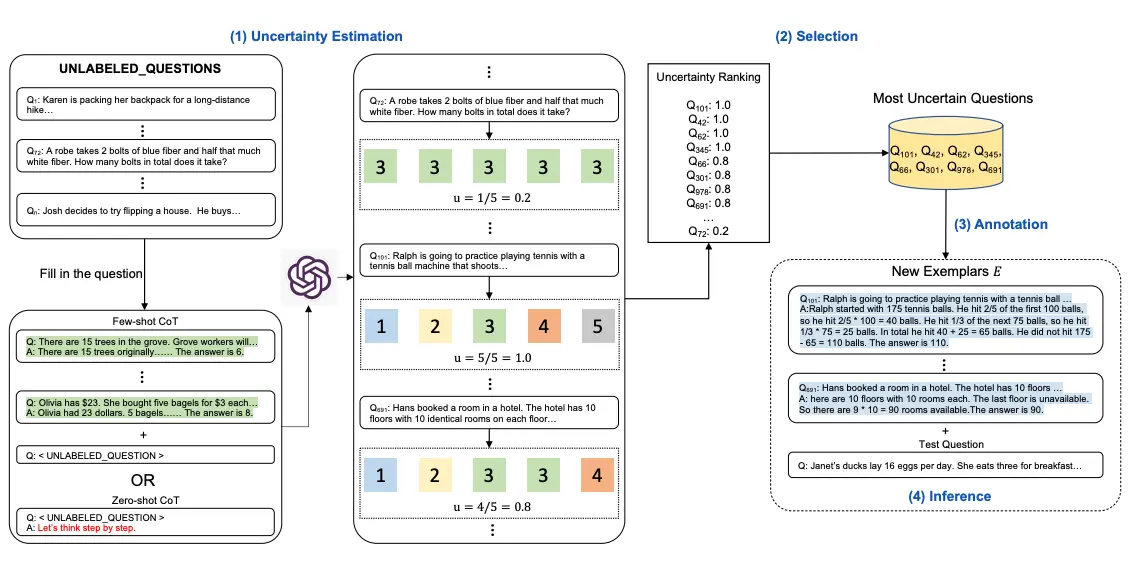

In [1]:
import json
import random
import re
import os
import time
import numpy as np
from scipy.stats import entropy
from openai import OpenAI, APIError, RateLimitError

In [2]:
# 1. Configurations & Paths
# Insert your OpenAI API Key here

# File paths (You must upload these to Colab or map your Google Drive)
DATASET_PATH = "./dataset/GSM8K/train.jsonl"
PROMPT_PATH = "./dataset/math_word_problems.json"
TEST_DATASET_PATH = "./dataset/GSM8K/test.jsonl"
OUTPUT_DIR = "./output"

# Execution arguments
INFERENCE_MODEL = "gpt-4o-mini"
REASONING_MODEL = "gpt-4o"  # Better at structured JSON output for annotations
DATASET = "gsm8k"
RANDOM_SEED = 42

# Active-Prompt Hyperparameters
NUM_TRAILS = 5            # Number of reasoning paths for uncertainty estimation
TOP_K_SAMPLES = 5         # Number of difficult questions to annotate for the new prompt
MAX_TOKENS_COT = 256
TEMPERATURE_UNCERTAINTY = 0.7  # High temperature to generate diverse reasoning paths
TEMPERATURE_INFERENCE = 0.0    # Greedy decoding for final evaluation
API_TIME_INTERVAL = 1.0
NO_SOLUTION = "-10086"

# Limits for Colab Testing (Set to None or 0 to process the whole dataset)
TRAIN_LIMIT = 20  # Only evaluate 20 training questions to find uncertainty
TEST_LIMIT = 20   # Only evaluate 20 test questions in final inference

# Generated File Paths
os.makedirs(OUTPUT_DIR, exist_ok=True)
UNCERTAINTY_FILE = f"{OUTPUT_DIR}/uncertainty_result_{DATASET}_k{NUM_TRAILS}.json"
ACTIVE_PROMPT_FILE = f"{OUTPUT_DIR}/active_prompt_{DATASET}.json"
FINAL_RESULTS_FILE = f"{OUTPUT_DIR}/final_inference_results.json"

client = OpenAI()

In [3]:
# 2. Utility functions
def set_random_seed(seed: int):
    """Sets the random seed for deterministic sampling."""
    random.seed(seed)
    np.random.seed(seed)

def load_gsm8k_data(path: str):
    """Loads GSM8K dataset strictly from a jsonl file."""
    questions = []
    answers = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            questions.append(data["question"].strip())
            # Extracts the numeric answer located after '#### '
            answers.append(data["answer"].split("#### ")[-1].replace(",", ""))
    return questions, answers

def create_few_shot_prompt(path: str) -> str:
    """Reads the few-shot JSON file and formats the input prompt."""
    prompt_text = ""
    with open(path, 'r', encoding="utf-8") as f:
        json_data = json.load(f).get("prompt", [])
        
    for line in json_data:
        q = line["question"]
        r = line["rationale"]
        ans = line["pred_ans"]
        prompt_text += f"Q: {q}\nA: {r} The answer is {ans}.\n\n"
        
    return prompt_text

def answer_extraction_gsm8k(text: str) -> str:
    """Extracts the final numeric answer from the generated reasoning path."""
    text = text.replace(",", "")
    matches = re.findall(r'-?\d+\.?\d*', text)
    
    if matches:
        answer = matches[-1]
        if answer.endswith("."):
            answer = answer[:-1]
        try:
            return str(round(float(answer)))
        except ValueError:
            return "" 
    return ""

def chatgpt_request_with_retry(prompt: str, model: str, temperature: float, response_format=None) -> str:
    """Handles API calls to the modern OpenAI Chat API with basic retry handling."""
    messages = [{"role": "user", "content": prompt}]
    done = False
    
    kwargs = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": MAX_TOKENS_COT,
        "top_p": 1.0,
    }
    if response_format:
        kwargs["response_format"] = response_format

    while not done:
        try:
            response = client.chat.completions.create(**kwargs)
            return response.choices[0].message.content
        except RateLimitError:
            print("Rate limit reached. Sleeping...")
            time.sleep(API_TIME_INTERVAL * 5)
        except APIError as e:
            print(f"API Error: {e}")
            time.sleep(API_TIME_INTERVAL * 2)
        except Exception as e:
            print(f"Unexpected Error: {e}")
            raise e

In [4]:
# 3. Phase 1: Uncertainty estimation

def estimate_uncertainty():
    print(f"\n--- Phase 1: Uncertainty Estimation ({NUM_TRAILS} trails per question) ---")
    
    questions, answers = load_gsm8k_data(DATASET_PATH)
    dataset = [{"question": q, "answer": a, "question_idx": i} for i, (q, a) in enumerate(zip(questions, answers))]
    random.shuffle(dataset)
    
    if TRAIN_LIMIT and len(dataset) > TRAIN_LIMIT:
        dataset = dataset[:TRAIN_LIMIT]
    
    given_prompt = create_few_shot_prompt(PROMPT_PATH)
    results = []
    
    for count, qes in enumerate(dataset):
        if count % 5 == 0: print(f"Processing question {count}/{len(dataset)}...")
            
        uncertainty_record = {
            'dataset_idx': qes['question_idx'],
            'occurrence': {}
        }
        
        for trail in range(NUM_TRAILS):
            full_prompt = given_prompt + "Q: " + qes['question'] + "\nA: Let's think step by step."
            response_text = chatgpt_request_with_retry(full_prompt, INFERENCE_MODEL, TEMPERATURE_UNCERTAINTY)
            pred_ans = answer_extraction_gsm8k(response_text)
            
            if pred_ans == "": pred_ans = NO_SOLUTION
                
            if pred_ans in uncertainty_record['occurrence']:
                uncertainty_record['occurrence'][pred_ans] += 1
            else:
                uncertainty_record['occurrence'][pred_ans] = 1
                
        # Calculate Disagreement
        uncertainty_record['disagreement'] = len(uncertainty_record['occurrence'])
        results.append(uncertainty_record)

    # Sort by disagreement (highest uncertainty first)
    results.sort(key=lambda x: -x['disagreement'])
    
    with open(UNCERTAINTY_FILE, 'w', encoding='utf-8') as f:
        json.dump(results, f, indent=4)
        
    print(f"Phase 1 Complete. Results saved to {UNCERTAINTY_FILE}")

In [5]:
# 4. Phase 2: Automatic Expert Annotation

def automatic_annotation():
    print(f"\n--- Phase 2: Automatic Annotation with {REASONING_MODEL} ---")
    
    with open(UNCERTAINTY_FILE, 'r') as f:
        uncertainty_results = json.load(f)
    
    difficult_samples = uncertainty_results[:TOP_K_SAMPLES]
    
    questions_map = {}
    with open(DATASET_PATH, 'r') as f:
        for i, line in enumerate(f):
            questions_map[i] = json.loads(line)["question"]

    active_prompt_data = {"prompt": []}

    for i, sample in enumerate(difficult_samples):
        idx = sample['dataset_idx']
        question = questions_map[idx]
        print(f"Annotating question {i+1}/{TOP_K_SAMPLES}...")
        
        prompt = (
            f"Solve the following math problem step by step. Provide a clear reasoning and the final numeric answer.\n\n"
            f"Question: {question}\n\n"
            f"Return the result STRICTLY in JSON format with two keys: 'rationale' (string) and 'pred_ans' (string with the final number).\n"
        )

        try:
            response_text = chatgpt_request_with_retry(
                prompt=prompt, 
                model=REASONING_MODEL, 
                temperature=0.0, 
                response_format={ "type": "json_object" }
            )
            annotation = json.loads(response_text)
            
            active_prompt_data["prompt"].append({
                "question": question,
                "rationale": annotation.get("rationale", ""),
                "pred_ans": annotation.get("pred_ans", "")
            })
        except Exception as e:
            print(f"Error annotating index {idx}: {e}")

    with open(ACTIVE_PROMPT_FILE, 'w') as f:
        json.dump(active_prompt_data, f, indent=4)
    
    print(f"Phase 2 Complete. Active-Prompt created at {ACTIVE_PROMPT_FILE}")

In [6]:
# 5. Phase 3: Final inference

def run_final_inference():
    print(f"\n--- Phase 3: Final Inference with {INFERENCE_MODEL} ---")
    
    # Load the newly created Active-Prompt
    expert_prompt_str = create_few_shot_prompt(ACTIVE_PROMPT_FILE)

    test_questions = []
    with open(TEST_DATASET_PATH, 'r') as f:
        for line in f:
            test_questions.append(json.loads(line))

    if TEST_LIMIT and len(test_questions) > TEST_LIMIT:
        test_questions = test_questions[:TEST_LIMIT]
    
    final_results = []
    correct_count = 0

    for i, item in enumerate(test_questions):
        question = item["question"]
        ground_truth = item["answer"].split("#### ")[-1].replace(",", "").strip()
        
        full_input = expert_prompt_str + f"Q: {question}\nA: Let's think step by step."
        if i == 0:
            print("\n" + "="*50)
            print("INSPECTION: FINAL PROMPT SENT TO THE MODEL")
            print("="*50)
            print(full_input)
            print("="*50 + "\n")

        response_text = chatgpt_request_with_retry(full_input, INFERENCE_MODEL, TEMPERATURE_INFERENCE)
        pred_ans = answer_extraction_gsm8k(response_text)
        
        is_correct = (pred_ans == ground_truth)
        if is_correct: correct_count += 1
        
        final_results.append({
            "question": question,
            "prediction": pred_ans,
            "ground_truth": ground_truth,
            "correct": is_correct
        })
        
        if (i+1) % 5 == 0:
            print(f"Evaluated {i+1}/{len(test_questions)} | Accuracy: {round(correct_count/(i+1)*100, 2)}%")

    accuracy = correct_count / len(test_questions)
    
    with open(FINAL_RESULTS_FILE, 'w') as f:
        json.dump({"accuracy": accuracy, "details": final_results}, f, indent=4)

    print(f"\n--- Pipeline Complete ---")
    print(f"Final Accuracy: {round(accuracy * 100, 2)}%")

In [7]:
set_random_seed(RANDOM_SEED)
    
# 1. Estimate uncertainty on training data
estimate_uncertainty()

# 2. Generate expert reasoning for difficult questions
if os.path.exists(UNCERTAINTY_FILE):
    automatic_annotation()
else:
    print("Failed to run Phase 2: Uncertainty file missing.")
    
# 3. Test the model using the new generated prompt
if os.path.exists(ACTIVE_PROMPT_FILE):
    run_final_inference()
else:
    print("Failed to run Phase 3: Active Prompt file missing.")


--- Phase 1: Uncertainty Estimation (5 trails per question) ---
Processing question 0/20...
Processing question 5/20...
Processing question 10/20...
Processing question 15/20...
Phase 1 Complete. Results saved to ./output/uncertainty_result_gsm8k_k5.json

--- Phase 2: Automatic Annotation with gpt-4o ---
Annotating question 1/5...
Annotating question 2/5...
Annotating question 3/5...
Annotating question 4/5...
Annotating question 5/5...
Phase 2 Complete. Active-Prompt created at ./output/active_prompt_gsm8k.json

--- Phase 3: Final Inference with gpt-4o-mini ---

INSPECTION: FINAL PROMPT SENT TO THE MODEL
Q: John wants to start a zoo.  He has 15 snakes.  He has twice as many monkeys as he does snakes.  He has 5 fewer lions than he does monkeys.   John has 8 more pandas than he does lions.  John has 1/3 as many dogs as he does pandas.  How many total animals does John have?
A: John has 15 snakes. He has twice as many monkeys as snakes, so he has 15 * 2 = 30 monkeys. He has 5 fewer lion